# Name
Please write your name down here:

Peter Brederlow

**Throwback: which SNPs are associated with mouse coat color?**

This is the final notebook. It's a tiny excercise to revisit an older analysis with a new approach.

Remember the GWAS task from day 3, where we investigated which SNPs were associated with the black coat color of mice? Back then, we found them with methodical statistical testing. This time we'll find them with the help of random forests.

We know random forests are useful to determine the importance of different features for classifying samples. Therefore we could train a random forest to predict hair color from genotype data, and then look at what features it considered important while doing it.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
import seaborn as sns
from dtreeviz.trees import model

In [16]:
color_palette = ["#433c82", "#bd4d4d", "#facb7f", "#6b8fc2"]

Load the genotype and color data.

In [17]:
genotype = pd.read_csv(
    "https://raw.githubusercontent.com/Practical-Integrative-Bioinformatics/Introduction/main/data/genotype.txt", 
    sep="\t", 
    comment="@", 
    index_col="Locus"
)
colors = pd.read_csv(
    "https://raw.githubusercontent.com/Practical-Integrative-Bioinformatics/00_Introduction/main/data/coat_color.csv", 
    index_col=0, 
    names=["color"], 
    na_values='x'
).dropna()['color']

Split the genotype data into two dataframes: `geno_meta` with the metadata (first 3 columns) and `geno` with the actual genotype data, encoded with B:0, U/H:1, D:2.

Since `sklearn` takes samples in rows, and our samples correspond to mice strains here, we transpose `geno`. We also want to make sure that the indices of `geno` and `color` line up with each other: we only keep the intersection of their indices.

In [18]:
geno_meta = genotype.iloc[:,:3]
geno = genotype.iloc[:, 3:].replace({'B': 0, 'U': 1, 'H': 1, 'D': 2}).T

shared_idx = geno.index.intersection(colors.index)

data = geno.loc[shared_idx]
data

Locus,rs6269442,rs6365999,rs6376963,rs3677817,rs8236463,rs6333200,rs6298633,rs6241531,rs6360236,rs3722996,...,CEL-X_143438541,CEL-X_143595976,rs13484097,gnfX.141.820,CEL-X_154048891,CEL-X_154259201,rs3657281,rs13484106,gnfX.146.867,DXMit223
BXD1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BXD2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BXD5,2,2,2,2,2,2,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0
BXD6,2,2,2,2,2,2,2,2,2,2,...,0,0,0,0,0,2,2,2,2,2
BXD8,2,2,2,2,2,2,2,2,2,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BXD98,0,0,0,0,0,0,0,0,0,0,...,2,2,2,2,2,2,2,2,2,2
BXD99,0,0,0,0,0,0,0,0,0,0,...,0,2,2,2,2,2,2,2,2,2
BXD100,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BXD101,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1


As for encoding colors: they are already numbers. We won't even transform them to the binary black/non-black labels like we did on day 3, we will just feed them to the predictor as they are. Let the random forest figure out the associations for black/grey/white/brown.

For reference, the color encoding was:

|color  | value |
|-------|-------|
| dilute|  1    |
| brown |  2    |
| grey  |  3    |
| black |  4    |

It's a good idea to use a traditional 0/1/2/3 encoding for compatibility with tools that might rely on that assumption (e.g. dtreeviz), so create `target` by subtracting 1 from `colors`.

In [19]:
target = colors.loc[shared_idx] - 1

# Train a random forest with the genotype data

Train a random forest classifier with all the data. Make sure you use a lot of trees in that forest (1000+ should be good) so you can get fine-grained values for feature importances. The more decision trees you create during training, the clearer it gets which features are most useful.

In [20]:
# YOUR CODE HERE
rf = RandomForestClassifier(n_estimators=2000, random_state=42)
rf.fit(data, target)
rskf = RepeatedStratifiedKFold(n_splits=3, n_repeats=10, random_state=42)
acc = cross_val_score(rf, data, target, cv=rskf)
print(f"Mean CV accuracy: {np.mean(acc):.3f}")
print(f"Std CV accuracy: {np.std(acc):.3f}")

Mean CV accuracy: 0.876
Std CV accuracy: 0.049


## Insert feature importances into `geno_meta`
Now take the feature importance vector, and add it to the `geno_meta` DataFrame as a new column `importance`. Sort the DataFrame by that column in descending order, and look at the most important SNP locations. Compare them with your old GWAS analysis -- no need to load anything, just look at the top hits, or the old Manhattan plot.

If you feel like creating a new Manhattan plot with the feature importances, go ahead, lift over your old code and change it such that it plots `importance` on the y-axis instead of those old -log10 p-values.

Locus
rs3724833         0.015544
rs3725904         0.015087
rs13477785        0.013164
rs13480283        0.012839
rs13480279        0.012767
CEL-4_74121566    0.012728
rs3708061         0.012353
CEL-4_74066970    0.012219
rs13477796        0.011841
rs3685573         0.010849
rs3670437         0.010745
rs3658567         0.010327
rs13480277        0.009994
rs13477805        0.009981
rs3674482         0.009710
rs13480288        0.009476
rs13477804        0.009238
rs13480291        0.008299
rs6167970         0.008204
gnf09.074.193     0.007721
dtype: float64
Top 20 most important features:
Locus
rs3724833         0.015544
rs3725904         0.015087
rs13477785        0.013164
rs13480283        0.012839
rs13480279        0.012767
CEL-4_74121566    0.012728
rs3708061         0.012353
CEL-4_74066970    0.012219
rs13477796        0.011841
rs3685573         0.010849
rs3670437         0.010745
rs3658567         0.010327
rs13480277        0.009994
rs13477805        0.009981
rs3674482         0.009

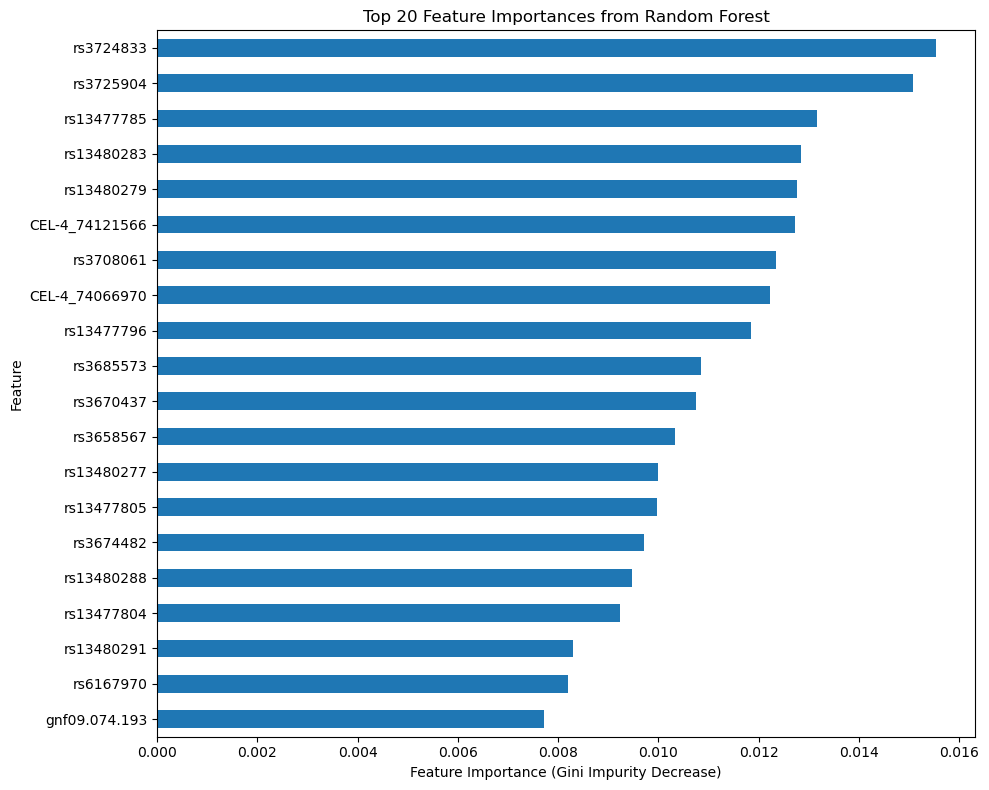

In [21]:
# YOUR CODE HERE
feature_importances = pd.Series(rf.feature_importances_, index=data.columns)
feature_importances_sorted = feature_importances.sort_values(ascending=False)
print(feature_importances_sorted.head(20))

print("Top 20 most important features:")
print(feature_importances_sorted.head(20))
plt.figure(figsize=(10, 8))
feature_importances_sorted.head(20).plot(kind='barh')
plt.xlabel('Feature Importance (Gini Impurity Decrease)')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances from Random Forest')
plt.gca().invert_yaxis()  # Most important at top
plt.tight_layout()
plt.show()


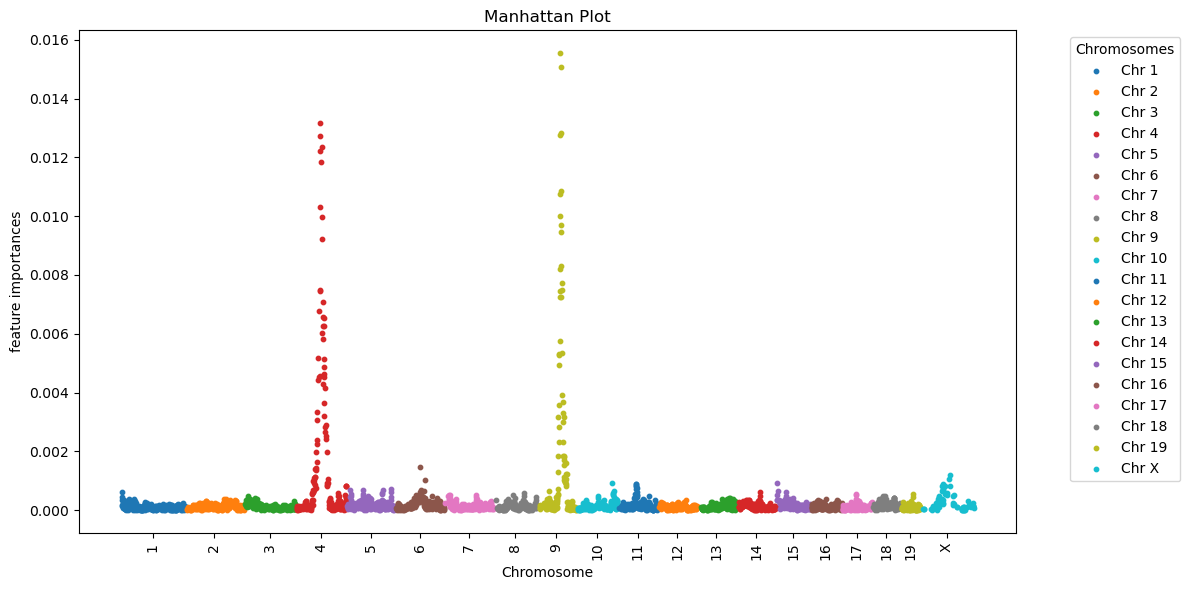

In [22]:
geno_meta['feature_importance'] = feature_importances.values
geno_meta['Chr'] = geno_meta['Chr'].astype(str)
chromosome_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
geno_meta['Chr'] = pd.Categorical(geno_meta['Chr'], categories=chromosome_order, ordered=True)
geno_meta
chromosome_offsets = geno_meta.groupby('Chr')['Mb'].max().cumsum().shift(fill_value=0)
chromosome_midpoints = chromosome_offsets + geno_meta.groupby('Chr')['Mb'].max() / 2
geno_meta['cumulative_mb'] = geno_meta['Mb'] + geno_meta['Chr'].map(chromosome_offsets)

plt.figure(figsize=(12, 6))
for chrom, group in geno_meta.groupby('Chr'):
    plt.scatter(group['cumulative_mb'], group['feature_importance'], s=10, label=f'Chr {chrom}')
plt.xlabel('Chromosome')
plt.xticks(chromosome_midpoints, chromosome_midpoints.index, rotation=90)
plt.ylabel('feature importances')
plt.title('Manhattan Plot')
plt.legend(title='Chromosomes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Internally, the feature importances are based on the decrese in the impurity of the tree with Gini Impurity Index:  
$$ G = 1 - \left(p_1^2 + p_2^2 + \cdots + p_K^2\right) $$ with $$ p_i = \frac{n_i}{n} $$ 
Here n is the total amount of labels, and n_i is the amount of samples assigned to the respective label. So the most informative features lead to a decrease in the label assignments.  
Interestingly, just as with the GWAS-tests we performed, the majority of informative features is located on chromosomes 4 and 9. This probably reflects the SNPs in linkage disqulibrium with Tyrp1 and Rab27a, which encode dilute and the amount of melanin. 




Strobel MC, Seperack PK, Moore KJ, Copeland NG, Jenkins NA. The dilute coat-color locus of mouse chromosome 9. Prog Clin Biol Res. 1988;256:297-305. PMID: 3368491.  

Geisert, E. E., Lu, L., Freeman-Anderson, N. E., Templeton, J. P., Nassr, M., Wang, X., Gu, W., Jiao, Y., & Williams, R. W. (2009). Gene expression in the mouse eye: an online resource for genetics using 103 strains of mice. Molecular Vision, 15, 1730. https://pmc.ncbi.nlm.nih.gov/articles/PMC2736153/


## Evaluate the model
If you took the effort to create a random forest, you might as well evaluate its performance.

* Calculate a cross-validated accuracy score
* Create a confusion matrix for the four colors using `sklearn.metrics.confusion_matrix` or `pd.crosstab`. You can lower the number of trees used by an order of magnitude (say, down to 100), since cross-validation makes things more time intensive.

In [23]:
# YOUR CODE HERE
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
preds = cross_val_predict(rf, data, target, cv = skf)
conf = confusion_matrix(target, preds)
print("Confusion Matrix:")
print(conf)
print("\nClassification Report:")
print(classification_report(target, preds))


Confusion Matrix:
[[30  0  0  0]
 [ 1 21  0  1]
 [ 2  0 14  2]
 [ 0  1  2 16]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95        30
         1.0       0.95      0.91      0.93        23
         2.0       0.88      0.78      0.82        18
         3.0       0.84      0.84      0.84        19

    accuracy                           0.90        90
   macro avg       0.90      0.88      0.89        90
weighted avg       0.90      0.90      0.90        90



The Random Forest here leads to almost perfect color predictions, with just 4 misclasifications overall. This is predicted in Recall, Precision and F1 score being close to 1. Especially for the colors dilute and brown.

# Optional, and boring: ROC diagrams

We know how to make ROC curves for binary classification tasks, when one of the two classes is treated as positive, and the other as negative.

However, this isn't a binary classification task. We have four labels for the four colors. So if you really want to produce a ROC diagram, you'll have to create four ROC diagrams, where in each plot, positive = given color, negative = everything else.

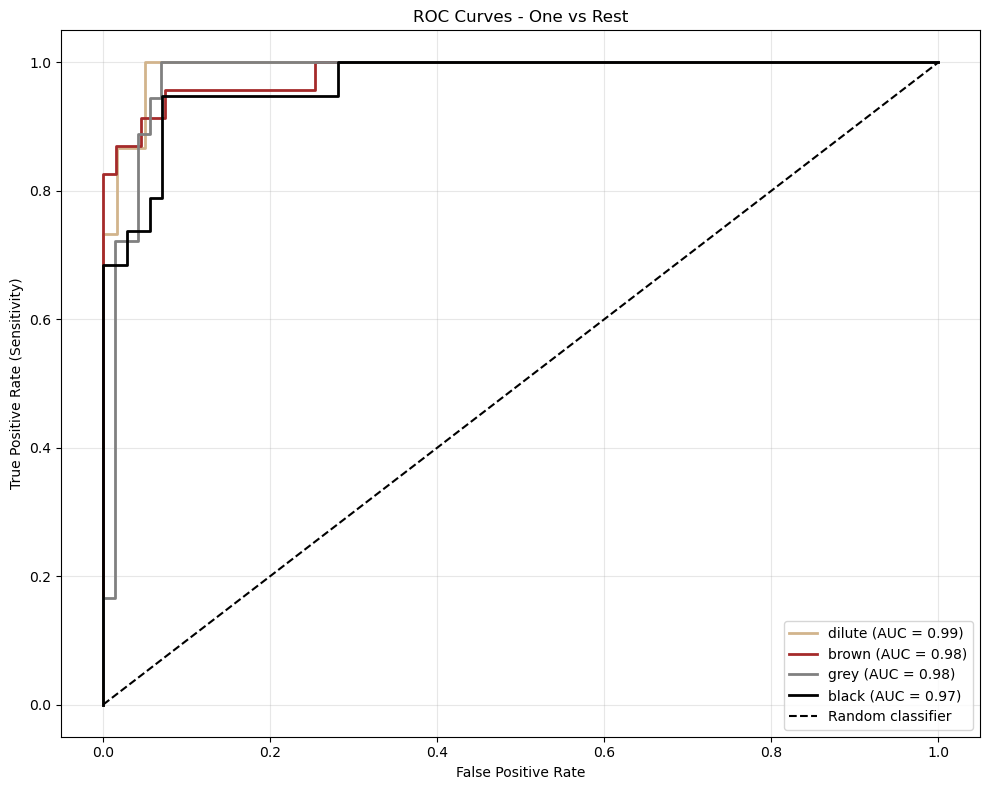

In [24]:
# YOUR CODE HERE
proba = cross_val_predict(rf, data, target, cv=skf, method='predict_proba')
class_names = ['dilute', 'brown', 'grey', 'black']
value_to_color = {
    4: 'black',
    3: 'grey',
    2: 'brown',
    1: 'tan',
}
color_palette = [value_to_color[i] for i in range(1, 5)]

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    y_binary = (target == i).astype(int)
    y_score = proba[:, i]
    fpr, tpr, _ = roc_curve(y_binary, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color_palette[i], label=f'{class_name} (AUC = {roc_auc:.2f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves - One vs Rest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The really good prediciton accuracies are also reflected here, with an AUROC of 0.97 to 0.99, so almost perfect, for all four colors.

## Optional, but interesting: find the minimal causative model

Coat color seems to be governed by a small number of SNPs on chromosome 4 and 9, only one on each chromosome in fact. Try to create a minimal model to explain the coat phenotype with. Find the SNP with the highest importance on chr4 and chr9 each, create a dataset reduced to only these two features. Train a decision tree (or a random "forest" with just one tree) on this data, and visualize it with `dtreeviz`.

In [25]:
# YOUR CODE HERE
geno_meta_9 = geno_meta[geno_meta['Chr'] == '9']
max_feature_9 = geno_meta_9['feature_importance'].max()
print(max_feature_9)
max_feature_9_index = geno_meta_9['feature_importance'].idxmax()
print(max_feature_9_index)

geno_meta_4 = geno_meta[geno_meta['Chr'] == '4']
max_feature_4 = geno_meta_4['feature_importance'].max()
print(max_feature_4)
max_feature_4_index = geno_meta_4['feature_importance'].idxmax()
print(max_feature_4_index)

top_loci = [max_feature_9_index, max_feature_4_index]
data_min = data[top_loci]
data_min

rf = RandomForestClassifier(n_estimators=500, random_state=69)
rf.fit(data_min, target)
preds_min = cross_val_predict(rf, data_min, target, cv=skf)
conf_min = confusion_matrix(target, preds_min)
print("Confusion Matrix with Top 2 Loci:")
print(conf_min)

acc = cross_val_score(rf, data_min, target, cv=skf)
print(f"Mean CV accuracy: {np.mean(acc):.3f}")
print(f"Std CV accuracy: {np.std(acc):.3f}")


0.015543663770746566
rs3724833
0.013164236260823211
rs13477785
Confusion Matrix with Top 2 Loci:
[[30  0  0  0]
 [ 1 21  0  1]
 [ 0  0 17  1]
 [ 0  0  1 18]]
Mean CV accuracy: 0.956
Std CV accuracy: 0.042


This is fairly impressive, 2 features are sufficient to find an almost perfectly predict the color of the mice. As we already discussed in worksheet 4, the fur color of mice is depending on very few, almost mendelian loci for Tyrp1 and Rab27a.